In [1]:
!pip install -q transformers accelerate bitsandbytes peft

In [2]:
import pandas as pd
from google.colab import files
import os
filename = "Q2_20230202_majority 1.csv"

if not os.path.exists(filename):
  print(f"'{filename}' not found. Please upload the file.")
  uploaded = files.upload()
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("Q2_20230202_majority 1.csv")
df.sample(5)

,tweet_id,created_at,tweet,label_majority,month
723,1.436094e+18,2021-09-09 22:28:54+00:00,i will not make my employees get vaccinated. ..i will not punish my clerks for making a personal healthcare decision. ..i will not comply. ..period.,against,21-Sep
529,1.431264e+18,2021-08-27 14:36:12+00:00,they can't hide all the vax reactions and deaths.,against,21-Aug
1279,1.448093e+18,2021-10-13 01:07:09+00:00,we cannot let this continue. lives are at stake. get vaccinated..,in-favor,21-Oct
914,1.439267e+18,2021-09-18 16:37:03+00:00,sturgeon nonsense logic strikes again. if vaccine passports not tests are vital to stop the spread of covid in nightclubs etc why is she insisting tests not double vaccination are required for travel?,against,21-Sep
2742,1.420953e+18,2021-07-30 03:41:57+00:00,"we are proud to announce the programming lineup for the 2021 outfest los angeles lgbtq film festival, august 13-22, with outdoor events, indoor screenings for vaccinated attendees, &amp; available for streaming. member tickets on sale now at 🌈🔥",in-favor,21-Jul


In [3]:
import zipfile
import os

model_dir = "finetuned-flan-t5-vaccine"
zip_path = "/content/finetuned-flan-t5-vaccine.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(model_dir)

In [4]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(model_dir).eval()

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): lora.Linear(
                (base_layer): Linear(in_features=1024, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1024, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k): Linear(in_f

In [5]:
def format_prompt(tweet):
    prompt = f"""
      What is the stance of the following tweet with respect to COVID-19 vaccination?
      Tweet: "{tweet}"
      Please respond with exactly one of the following options:
        1: 'neutral-or-unclear' if it is unclear, mixed, or does not take a clear side
        2: 'in-favor' if it supports or promotes vaccines
        3: 'against' if it opposes or questions vaccines
    """
    return prompt

def map_prediction(pred, tweet):
    pred = pred.lower().strip()

    if any(k in pred for k in ["2", "favor", "inf", "in favor", "in-favor", "pro", "positive", "in-f"]):
        return "in-favor"
    elif any(k in pred for k in ["3", "against", "anti", "oppose", "negative"]):
        return "against"
    elif any(k in pred for k in ["1", "neutral", "unclear", "not sure", "unknown", "not-sure"]):
        return "neutral-or-unclear"
    else:
        print("Unknown: " + pred)
        return "unknown"

def normalize(text):
    return text.strip().lower().replace("-", "").replace("_", "").replace(" ", "")

def predict_stance(tweet, tokenizer, model):
    uncertainty_keywords = [
    "not sure", "unsure", "confused", "idk", "mixed feelings",
    "explain", "don’t understand", "trying to understand",
    "can someone", "why does", "how come", "what’s the deal"
    ]
    if any(kw in tweet.lower() for kw in uncertainty_keywords):
        return map_prediction('neutral-or-unclear', tweet)
    prompt = format_prompt(tweet)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=8)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return map_prediction(prediction, tweet)

print("functions loaded")

functions loaded


In [6]:
sample_tweets = [
    "I'm really happy I got my COVID-19 vaccine today!",
    "The government forcing vaccines is just wrong.",
    "I heard mixed things about the vaccine, still unsure if I should take it."
]

for tweet in sample_tweets:
    prediction = predict_stance(tweet, tokenizer, model)
    print(f"\nTweet: {tweet}")
    print(f"Predicted Sentiment: {prediction}")


Tweet: I'm really happy I got my COVID-19 vaccine today!
Predicted Sentiment: in-favor

Tweet: The government forcing vaccines is just wrong.
Predicted Sentiment: against

Tweet: I heard mixed things about the vaccine, still unsure if I should take it.
Predicted Sentiment: neutral-or-unclear


In [7]:
from tqdm import tqdm

preds = []
labels = []
wrong = []

df_test1 = df.sample(500)

print("Generating predictions...")
for _, row in tqdm(df_test1.iterrows(), total=len(df_test1)):
    tweet = row['tweet']
    label = row['label_majority']

    prediction = predict_stance(tweet, tokenizer, model)
    mapped_pred = map_prediction(prediction, tweet)


    if (not mapped_pred == label): wrong.append("tweet: " + row['tweet'] + "pred: " + mapped_pred + "act: " + label)
    preds.append(mapped_pred)
    labels.append(label)

df_test1['predicted'] = preds

Generating predictions...


100%|██████████| 500/500 [02:11<00:00,  3.80it/s]



Validation Accuracy: 0.632

Prediction counts: Counter({'in-favor': 267, 'against': 224, 'neutral-or-unclear': 9})
Label counts:      Counter({'in-favor': 252, 'against': 158, 'neutral-or-unclear': 90})


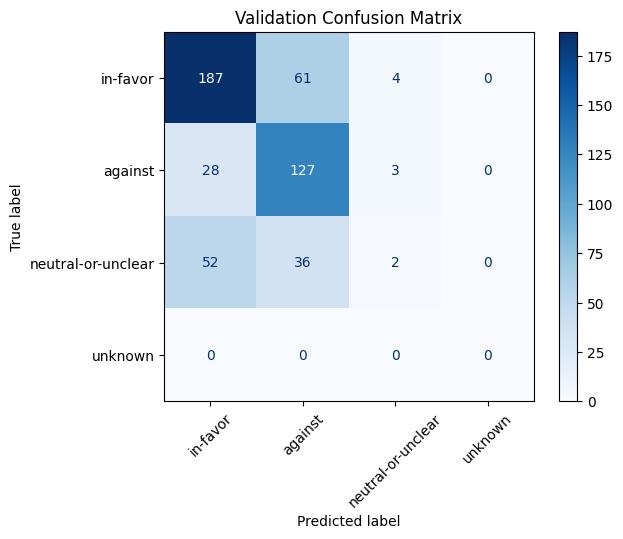

In [8]:
# Accuracy
correct = sum([
    normalize(p) == normalize(l)
    for p, l in zip(preds, labels)
])
accuracy = correct / len(labels)
print(f"\nValidation Accuracy: {accuracy:.3f}")

# Optional: show simple class distribution and mismatches
from collections import Counter
print("\nPrediction counts:", Counter(preds))
print("Label counts:     ", Counter(labels))

# Optional: show confusion matrix
try:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    cm = confusion_matrix(labels, preds, labels=["in-favor", "against", "neutral-or-unclear", "unknown"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["in-favor", "against", "neutral-or-unclear", "unknown"])
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Validation Confusion Matrix")
    plt.show()
except ImportError:
    print("Install `scikit-learn` and `matplotlib` for confusion matrix support.")
